# Adaptive Cost-Aware Context Selection (ACCS)

## Repository-Level Context Optimization for LLM Coding Agents

This notebook is self-contained within the submitted project package. All required modules and datasets are included, ensuring full reproducibility.

The objective is to reduce token usage while preserving important dependency relationships within a repository.

Two approaches are compared:
1. Baseline Breadth-First Search (BFS)
2. Proposed ACCS algorithm

### How to Run

This notebook uses the actual implementation from the project:
- `parser.ast_parser` - AST parsing
- `graph.graph_builder` - Dependency graph construction
- `retrieval.baseline_bfs` - Baseline BFS retrieval
- `retrieval.adaptive_budget` - Adaptive budget-aware retrieval
- `metrics.*` - Token estimation, context building, coverage metrics


The notebook should be executed from the submitted project package with the
required project directories available.

In [163]:
# Add project root to Python path (ensures imports work from any location)
import sys
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve()
except NameError:
    # __file__ is not defined in interactive mode (e.g., Jupyter Notebook)
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Standard libraries
import os
import json
from dataclasses import dataclass, field
from typing import Any
from collections import deque

# Third-party
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Module imports from the project
from parser.ast_parser import ASTParser
from graph.graph_builder import GraphBuilder, DependencyGraph
from graph.graph_search import GraphSearch
from retrieval.baseline_bfs import BaselineBFS
from retrieval.adaptive_budget import AdaptiveBudgetRetriever
from retrieval.scorer import ScoringConfig
from metrics.token_estimator import TokenEstimator
from metrics.context_builder import ContextBuilder
from metrics.dependency_coverage import DependencyCoverage

print("✓ All imports successful")
print(f"  Project root: {PROJECT_ROOT}")


✓ All imports successful
  Project root: /home/dilusha/projects/BGCR


In [164]:
# -----------------------------
# Step 1: Load dataset and build graph
# -----------------------------
# Purpose:
# Convert repository into a dependency graph where:
# - Nodes represent files, classes, and functions
# - Edges represent dependencies (imports, calls, inheritance)

REPO_PATH = str(PROJECT_ROOT / "sample_repo")

assert os.path.exists(REPO_PATH), f"Dataset not found at {REPO_PATH}"
assert os.path.isdir(REPO_PATH), f"{REPO_PATH} is not a directory"

print(f"Loading repository from: {REPO_PATH}\n")

# Step 1: Parse repository using production ASTParser
print("Step 1/4: Parsing repository...")
parser = ASTParser()
parsed_repo = parser.parse_directory(REPO_PATH)
print(f"  ✓ Parsed {len(parsed_repo.files)} files")

# Step 2: Build dependency graph using production GraphBuilder
print("\nStep 2/4: Building dependency graph...")
builder = GraphBuilder(parser)
graph = builder.build_from_parsed(parsed_repo)
print(f"  ✓ Graph: {graph.node_count} nodes, {graph.edge_count} edges")

# Show file nodes
file_nodes = graph.get_all_files()
print(f"\n  Files in graph: {len(file_nodes)}")
for fn in sorted(file_nodes):
    node_data = graph.get_node_data(fn)
    if node_data:
        print(f"    - {fn} (~{node_data.estimated_token_cost} tokens)")


Loading repository from: /home/dilusha/projects/BGCR/sample_repo

Step 1/4: Parsing repository...
  ✓ Parsed 8 files

Step 2/4: Building dependency graph...
  ✓ Graph: 76 nodes, 90 edges

  Files in graph: 8
    - analytics_service.py (~315 tokens)
    - auth_service.py (~637 tokens)
    - base_model.py (~305 tokens)
    - database_config.py (~270 tokens)
    - inventory_service.py (~298 tokens)
    - mfa_service.py (~416 tokens)
    - payment_service.py (~372 tokens)
    - user_repository.py (~415 tokens)


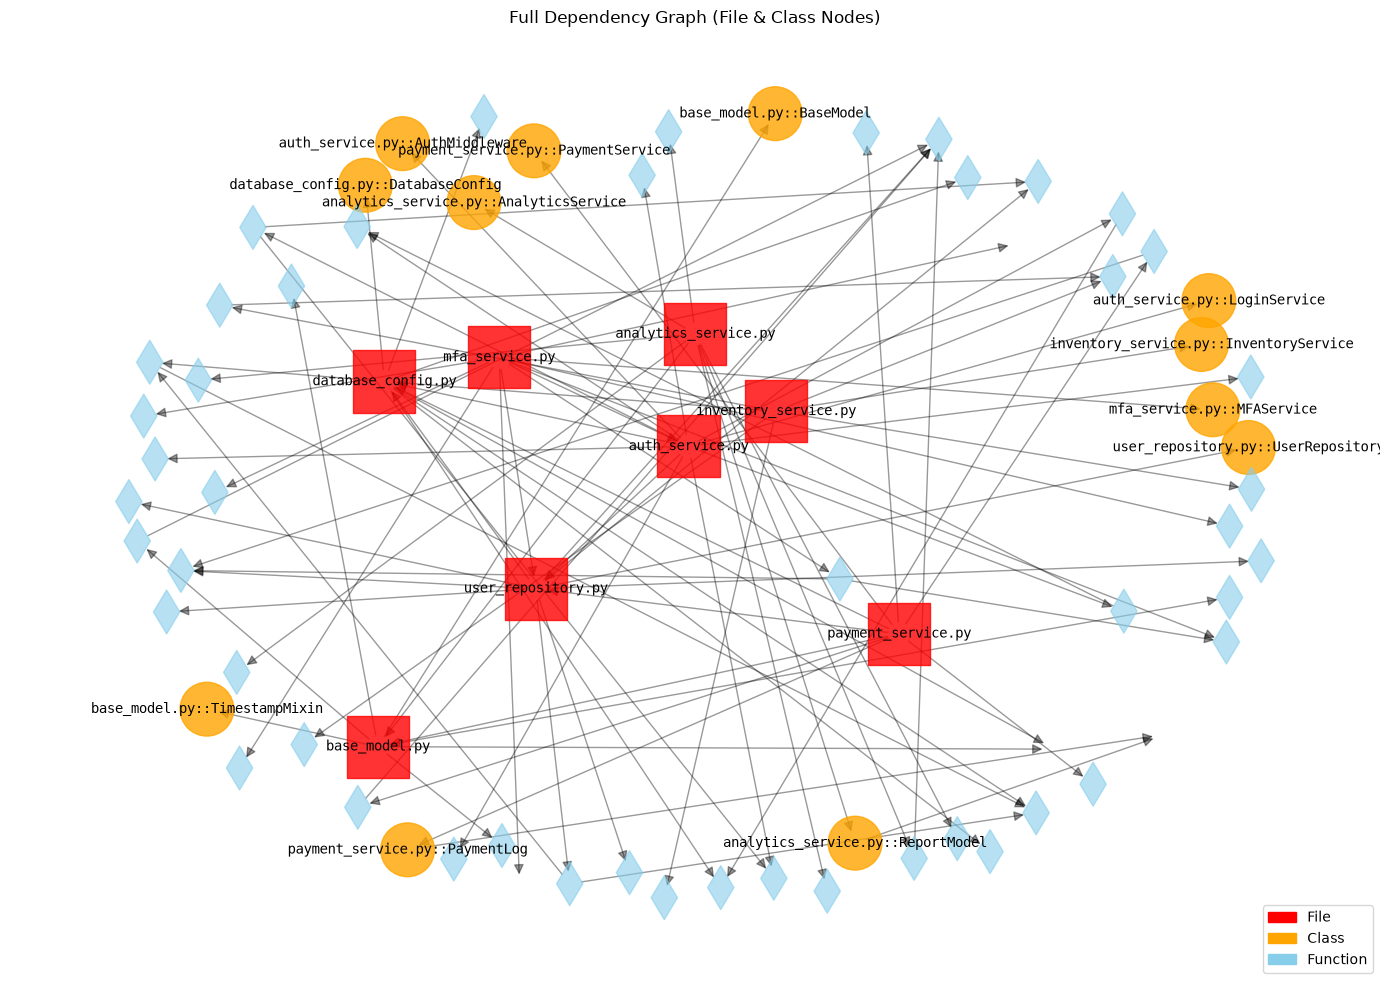


Nodes: 76
Edges: 90
  File nodes: 8
  Class nodes: 12
  Function nodes: 48


In [ ]:
# -----------------------------
# Step 3: Visualize full dependency graph
# -----------------------------

plt.figure(figsize=(14, 10))

# Better layout (more spacing)
pos = nx.spring_layout(graph.graph, k=1.5, seed=42)

# Color nodes by type
color_map = []
for node_id in graph.graph.nodes():
    node_type = graph.graph.nodes[node_id].get("node_type", "function")
    if node_type == "file":
        color_map.append("red")
    elif node_type == "class":
        color_map.append("orange")
    else:
        color_map.append("skyblue")

# Draw nodes by type for better visualization
file_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get("node_type") == "file"]
class_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get("node_type") == "class"]
func_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get("node_type") == "function"]

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=file_nodes_list,
    node_color=["red" for _ in file_nodes_list],
    node_size=2000,
    node_shape="s",
    alpha=0.8,
)

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=class_nodes_list,
    node_color=["orange" for _ in class_nodes_list],
    node_size=1500,
    node_shape="o",
    alpha=0.8,
)

nx.draw_networkx_nodes(
    graph.graph, pos,
    nodelist=func_nodes_list,
    node_color=["skyblue" for _ in func_nodes_list],
    node_size=500,
    node_shape="d",
    alpha=0.6,
)

nx.draw_networkx_edges(
    graph.graph, pos,
    arrows=True,
    arrowsize=15,
    alpha=0.4,
)

# Draw labels for file nodes only (keep it readable)
file_labels = {n: n for n in file_nodes_list}
nx.draw_networkx_labels(
    graph.graph, pos,
    labels=file_labels,
    font_size=10,
    font_family="monospace",
)

class_labels = {n: n for n in class_nodes_list}
nx.draw_networkx_labels(
    graph.graph, pos,
    labels=class_labels,
    font_size=10,
    font_family="monospace",
)


plt.title("Full Repository Dependency Graph")
plt.axis("off")
file_patch = mpatches.Patch(color='red', label='File')
class_patch = mpatches.Patch(color='orange', label='Class')
func_patch = mpatches.Patch(color='skyblue', label='Function')
plt.legend(handles=[file_patch, class_patch, func_patch], loc='lower right')
plt.tight_layout()
plt.show()

print(f"\nNodes: {graph.node_count}")
print(f"Edges: {graph.edge_count}")
print(f"  File nodes: {len(file_nodes_list)}")
print(f"  Class nodes: {len(class_nodes_list)}")
print(f"  Function nodes: {len(func_nodes_list)}")

In [166]:
# -----------------------------
# Step 4: Run baseline BFS and ACCS with multiple queries
# -----------------------------

TOKEN_BUDGET = 500
MAX_DEPTH = 5
TOP_K = 3

queries = [
    "How does auth works?",
    "How are payments processed?",
    "How is user data stored?",
    "How is MFA implemented?",
]

# Storage for all results
all_results = {}

for q in queries:
    print(f"\n{'='*60}")
    print(f"Query: {q}")
    print(f"{'='*60}\n")

    # Find start nodes
    matches = GraphSearch.search(graph, q)
    start_nodes = GraphSearch.find_start_nodes(graph, q, top_k=TOP_K)

    if not start_nodes:
        print(f"  No matches found for query")
        all_results[q] = None
        continue

    print(f"  Found {len(start_nodes)} start node(s):")
    for i, sn in enumerate(start_nodes[:TOP_K]):
        node = graph.get_node_data(sn)
        node_type = node.node_type if node else "unknown"
        print(f"    {i+1}. [{node_type}] {sn}")

    # Baseline BFS
    baseline = BaselineBFS(graph, max_depth=MAX_DEPTH)
    baseline_result = baseline.retrieve(q, top_k=TOP_K)
    baseline_nodes = set(baseline_result.retrieved_nodes)
    baseline_tokens = baseline_result.token_estimate.total_tokens
    baseline_coverage = DependencyCoverage.calculate(graph, start_nodes, baseline_nodes)

    # Adaptive ACCS
    adaptive = AdaptiveBudgetRetriever(
        graph,
        budget=TOKEN_BUDGET,
        max_depth=MAX_DEPTH,
        importance_metric="pagerank",
        force_entry_node=False,
        tokenizer_mode="fast",
        scoring_config=ScoringConfig(None),
    )
    adaptive_result = adaptive.retrieve(q, top_k=TOP_K)
    adaptive_nodes = set(adaptive_result.retrieved_nodes)
    adaptive_tokens = adaptive_result.token_estimate.total_tokens
    adaptive_coverage = DependencyCoverage.calculate(graph, start_nodes, adaptive_nodes)

    baseline_cov_ratio = baseline_coverage.coverage_ratio if baseline_coverage else 0
    adaptive_cov_ratio = adaptive_coverage.coverage_ratio if adaptive_coverage else 0
    baseline_missing = len(baseline_coverage.missing_nodes) if baseline_coverage else 0
    adaptive_missing = len(adaptive_coverage.missing_nodes) if adaptive_coverage else 0

    all_results[q] = {
        "start_nodes": start_nodes,
        "baseline_nodes": baseline_nodes,
        "baseline_tokens": baseline_tokens,
        "baseline_coverage": baseline_cov_ratio,
        "baseline_missing": baseline_missing,
        "adaptive_nodes": adaptive_nodes,
        "adaptive_tokens": adaptive_tokens,
        "adaptive_coverage": adaptive_cov_ratio,
        "adaptive_missing": adaptive_missing,
    }

    print(f"\n  Baseline: {len(baseline_nodes)} nodes, {baseline_tokens} tokens, {baseline_cov_ratio:.2%} coverage")
    print(f"  ACCS:     {len(adaptive_nodes)} nodes, {adaptive_tokens} tokens, {adaptive_cov_ratio:.2%} coverage")

    if baseline_tokens > 0:
        reduction = (1 - adaptive_tokens / baseline_tokens) * 100
        print(f"  Reduction: {reduction:.1f}%")

# Store for later cells
first_query = queries[0]
if all_results.get(first_query):
    start_nodes = all_results[first_query]["start_nodes"]
    baseline_nodes = all_results[first_query]["baseline_nodes"]
    adaptive_nodes = all_results[first_query]["adaptive_nodes"]
    baseline_tokens = all_results[first_query]["baseline_tokens"]
    adaptive_tokens = all_results[first_query]["adaptive_tokens"]
    baseline_cov_ratio = all_results[first_query]["baseline_coverage"]
    adaptive_cov_ratio = all_results[first_query]["adaptive_coverage"]
    baseline_missing = all_results[first_query]["baseline_missing"]
    adaptive_missing = all_results[first_query]["adaptive_missing"]
else:
    print("No results loaded!")
    start_nodes = []
    baseline_nodes = set()
    adaptive_nodes = set()
    baseline_tokens = 0
    adaptive_tokens = 0
    baseline_cov_ratio = 0
    adaptive_cov_ratio = 0
    baseline_missing = 0
    adaptive_missing = 0



Query: How does auth works?

  Found 3 start node(s):
    1. [file] auth_service.py
    2. [class] auth_service.py::AuthMiddleware
    3. [function] auth_service.py::authenticate

  Baseline: 31 nodes, 1322.0 tokens, 100.00% coverage
  ACCS:     4 nodes, 353.0 tokens, 33.33% coverage
  Reduction: 73.3%

Query: How are payments processed?

  Found 2 start node(s):
    1. [class] auth_service.py::AuthMiddleware
    2. [class] payment_service.py::PaymentService

  Baseline: 2 nodes, 446.0 tokens, 100.00% coverage
  ACCS:     2 nodes, 446.0 tokens, 100.00% coverage
  Reduction: 0.0%

Query: How is user data stored?

  Found 3 start node(s):
    1. [file] user_repository.py
    2. [function] database_config.py::is_connected
    3. [class] user_repository.py::UserRepository

  Baseline: 19 nodes, 685.0 tokens, 100.00% coverage
  ACCS:     12 nodes, 486.0 tokens, 60.00% coverage
  Reduction: 29.1%

Query: How is MFA implemented?

  Found 3 start node(s):
    1. [function] mfa_service.py::dis

In [167]:
# -----------------------------
# Step 5: Compare results across all queries
# -----------------------------

print("\n" + "="*80)
print("  COMPARISON RESULTS ACROSS ALL QUERIES")
print("="*80)

# Filter to valid queries only
valid_queries = [q for q in queries if all_results.get(q) is not None]

if not valid_queries:
    print("\nNo results to compare")
else:
    # Print table headers
    print(f"\n{'Query':<35} {'Baseline':>10} {'ACCS':>10} {'Reduction':>12} {'Coverage':>12}")
    print("-"*80)

    baseline_tokens_list = []
    adaptive_tokens_list = []
    baseline_cov_list = []
    adaptive_cov_list = []

    for q in valid_queries:
        r = all_results[q]
        
        bt = r["baseline_tokens"]
        at = r["adaptive_tokens"]
        bc = r["baseline_coverage"]
        ac = r["adaptive_coverage"]
        
        reduction = (1 - at / bt) * 100 if bt > 0 else 0
        
        print(f"{q:<35} {bt:>10.0f} {at:>10.0f} {reduction:>11.1f}% {bc:.0%}→{ac:.0%}")
        
        baseline_tokens_list.append(bt)
        adaptive_tokens_list.append(at)
        baseline_cov_list.append(bc)
        adaptive_cov_list.append(ac)

    # Summary
    avg_baseline = sum(baseline_tokens_list) / len(baseline_tokens_list) if baseline_tokens_list else 0
    avg_adaptive = sum(adaptive_tokens_list) / len(adaptive_tokens_list) if adaptive_tokens_list else 0
    avg_reduction = (1 - avg_adaptive / avg_baseline) * 100 if avg_baseline > 0 else 0
    avg_baseline_cov = sum(baseline_cov_list) / len(baseline_cov_list) if baseline_cov_list else 0
    avg_adaptive_cov = sum(adaptive_cov_list) / len(adaptive_cov_list) if adaptive_cov_list else 0

    print("\n" + "-"*80)
    print(f"{'AVERAGE':<35} {avg_baseline:<10.0f} {avg_adaptive:<10.0f} {avg_reduction:<11.1f}% {avg_baseline_cov:.0%}→{avg_adaptive_cov:.0%}")
    print("-"*80)

    # CCR summary
    total_baseline = sum(baseline_tokens_list)
    total_adaptive = sum(adaptive_tokens_list)
    if total_baseline > 0:
        ccr = total_adaptive / total_baseline
        total_reduction = (1 - ccr) * 100
        print(f"\nOverall Context Compression Ratio (CCR): {ccr:.2f}")
        print(f"Total token reduction: {total_reduction:.1f}% ({total_baseline:.0f} → {total_adaptive:.0f} tokens)")

# Store for later cells using first valid query
if valid_queries:
    first_valid = valid_queries[0]
    r = all_results[first_valid]
    start_nodes = r["start_nodes"]
    baseline_nodes = r["baseline_nodes"]
    adaptive_nodes = r["adaptive_nodes"]
    baseline_tokens = r["baseline_tokens"]
    adaptive_tokens = r["adaptive_tokens"]
    baseline_cov_ratio = r["baseline_coverage"]
    adaptive_cov_ratio = r["adaptive_coverage"]
    baseline_missing = r["baseline_missing"]
    adaptive_missing = r["adaptive_missing"]
    display_query = first_valid
else:
    print("No results loaded!")
    start_nodes = []
    baseline_nodes = set()
    adaptive_nodes = set()
    baseline_tokens = 0
    adaptive_tokens = 0
    baseline_cov_ratio = 0
    adaptive_cov_ratio = 0
    baseline_missing = 0
    adaptive_missing = 0
    display_query = queries[0] if queries else ""

print(
    "\nNote: The per-query average reduction is the arithmetic mean of "
    "individual query reductions. The overall reduction is calculated "
    "from total baseline and ACCS tokens and therefore weights queries "
    "according to their token usage."
)


  COMPARISON RESULTS ACROSS ALL QUERIES

Query                                 Baseline       ACCS    Reduction     Coverage
--------------------------------------------------------------------------------
How does auth works?                      1322        353        73.3% 100%→33%
How are payments processed?                446        446         0.0% 100%→100%
How is user data stored?                   685        486        29.1% 100%→60%
How is MFA implemented?                   1738        416        76.1% 100%→33%

--------------------------------------------------------------------------------
AVERAGE                             1048       425        59.4       % 100%→57%
--------------------------------------------------------------------------------

Overall Context Compression Ratio (CCR): 0.41
Total token reduction: 59.4% (4191 → 1701 tokens)

Note: The per-query average reduction is the arithmetic mean of individual query reductions. The overall reduction is calculated fr

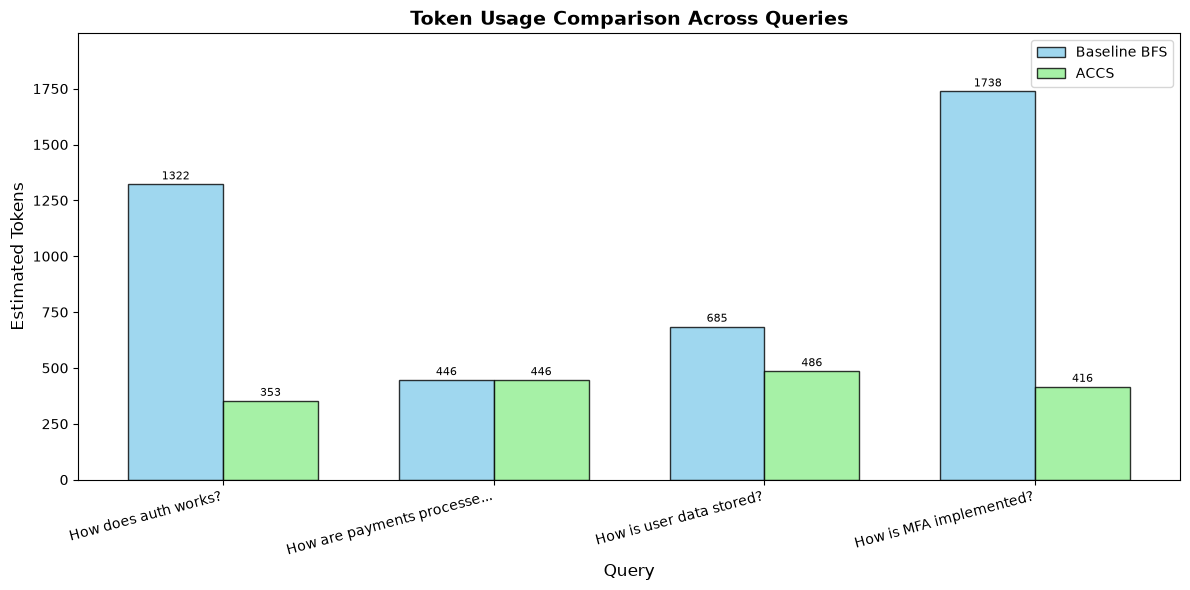

In [168]:
# -----------------------------
# Step 6: Visualize token comparison across all queries
# -----------------------------

# Filter to only queries with results
valid_queries = [q for q in queries if all_results.get(q) is not None]
valid_baseline = [all_results[q]["baseline_tokens"] for q in valid_queries]
valid_adaptive = [all_results[q]["adaptive_tokens"] for q in valid_queries]
valid_labels = [q[:25] + "..." if len(q) > 25 else q for q in valid_queries]
x = range(len(valid_queries))

if not valid_queries:
    print("No results to plot")
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    width = 0.35

    bars1 = ax.bar([i - width/2 for i in x], valid_baseline,
                   width, label='Baseline BFS', color='skyblue', edgecolor='black', alpha=0.8)
    bars2 = ax.bar([i + width/2 for i in x], valid_adaptive,
                   width, label='ACCS', color='lightgreen', edgecolor='black', alpha=0.8)

    # Add value labels
    for bar, val in zip(bars1, valid_baseline):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f"{val:.0f}", ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, valid_adaptive):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f"{val:.0f}", ha='center', va='bottom', fontsize=8)

    ax.set_title("Token Usage Comparison Across Queries", fontsize=14, fontweight='bold')
    ax.set_xlabel("Query", fontsize=12)
    ax.set_ylabel("Estimated Tokens", fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(valid_labels, rotation=15, ha='right')
    ax.legend()
    ax.set_ylim(0, max(max(valid_baseline), max(valid_adaptive)) * 1.15)
    plt.tight_layout()
    plt.show()


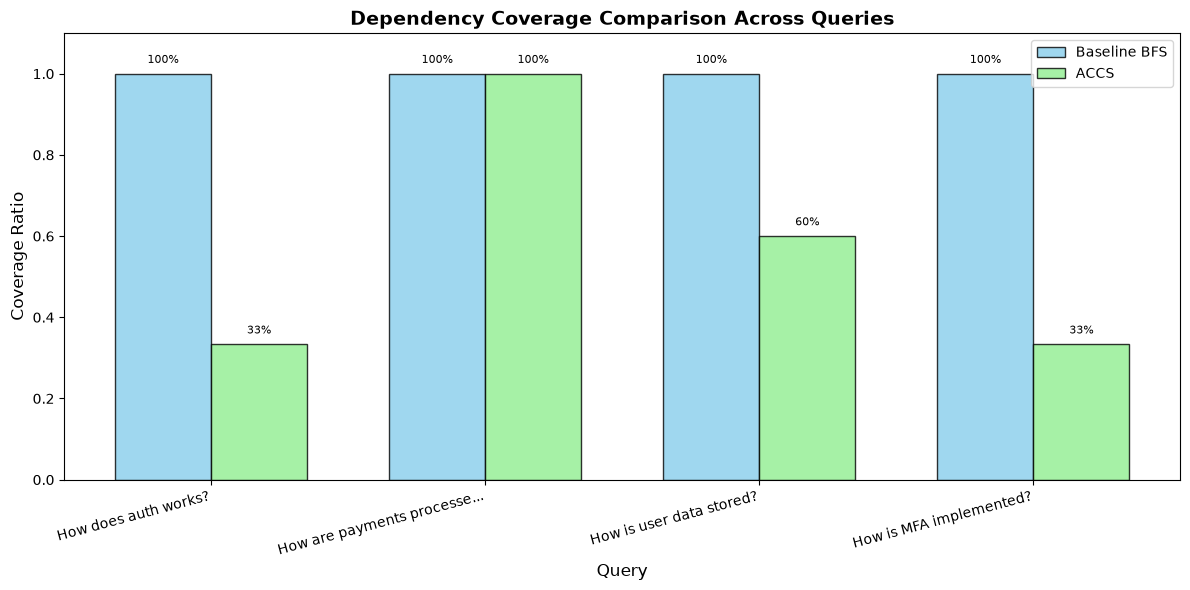

In [169]:
# -----------------------------
# Step 7: Visualize coverage comparison across all queries
# -----------------------------

if not valid_queries:
    print("No results to plot")
else:
    valid_cov_baseline = [all_results[q]["baseline_coverage"] for q in valid_queries]
    valid_cov_adaptive = [all_results[q]["adaptive_coverage"] for q in valid_queries]

    fig, ax = plt.subplots(figsize=(12, 6))
    width = 0.35

    bars1 = ax.bar([i - width/2 for i in x], valid_cov_baseline,
                   width, label='Baseline BFS', color='skyblue', edgecolor='black', alpha=0.8)
    bars2 = ax.bar([i + width/2 for i in x], valid_cov_adaptive,
                   width, label='ACCS', color='lightgreen', edgecolor='black', alpha=0.8)

    # Add value labels
    for bar, val in zip(bars1, valid_cov_baseline):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.0%}", ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, valid_cov_adaptive):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.0%}", ha='center', va='bottom', fontsize=8)

    ax.set_title("Dependency Coverage Comparison Across Queries", fontsize=14, fontweight='bold')
    ax.set_xlabel("Query", fontsize=12)
    ax.set_ylabel("Coverage Ratio", fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(valid_labels, rotation=15, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.show()


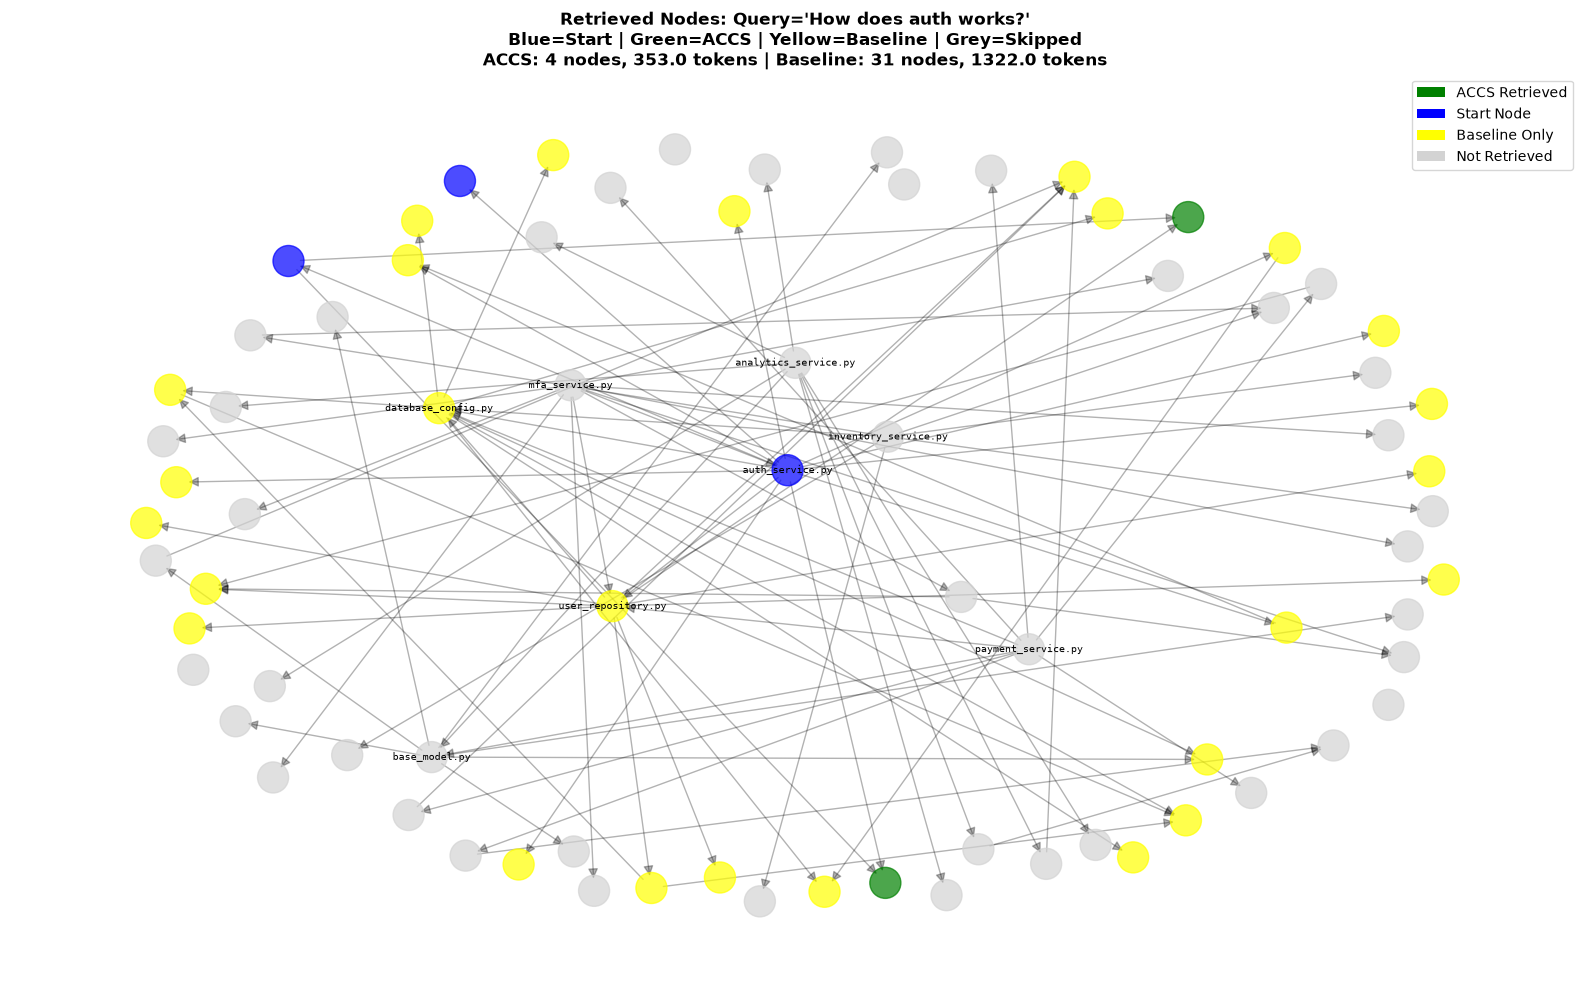

In [170]:
# -----------------------------
# Step 8: Visualize retrieved nodes on graph (first query)
# -----------------------------

display_result = all_results.get(display_query)

if not display_result:
    print("No results for first query")
else:
    dn = display_result["baseline_nodes"]
    an = display_result["adaptive_nodes"]
    dt = display_result["baseline_tokens"]
    at = display_result["adaptive_tokens"]

    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(graph.graph, k=1.5, seed=42)

    nodes_list = list(graph.graph.nodes())
    node_color_map = {}
    for sn in start_nodes:
        node_color_map[sn] = 'blue'
    for n in an:
        if n not in node_color_map:
            node_color_map[n] = 'green'
    for n in dn:
        if n not in node_color_map:
            node_color_map[n] = 'yellow'
    for n in nodes_list:
        if n not in node_color_map:
            node_color_map[n] = 'lightgrey'

    final_colors = [node_color_map.get(n, 'lightgrey') for n in nodes_list]

    nx.draw_networkx_nodes(
        graph.graph, pos,
        nodelist=nodes_list,
        node_color=final_colors,
        node_size=500,
        alpha=0.7,
    )

    nx.draw_networkx_edges(
        graph.graph, pos,
        arrows=True,
        arrowsize=15,
        alpha=0.3,
    )

    file_nodes_list = [n for n in graph.graph.nodes() if graph.graph.nodes[n].get('node_type') == 'file']
    file_labels = {n: n for n in file_nodes_list}
    nx.draw_networkx_labels(
        graph.graph, pos,
        labels=file_labels,
        font_size=7,
        font_family='monospace',
    )

    plt.title(
        f"Retrieved Nodes: Query='{display_query}'\n"
        f"Blue=Start | Green=ACCS | Yellow=Baseline | Grey=Skipped\n"
        f"ACCS: {len(an)} nodes, {at} tokens | Baseline: {len(dn)} nodes, {dt} tokens",
        fontsize=12, fontweight='bold'
    )
    plt.axis('off')

    legend_elements = [
        mpatches.Patch(facecolor='green', label='ACCS Retrieved'),
        mpatches.Patch(facecolor='blue', label='Start Node'),
        mpatches.Patch(facecolor='yellow', label='Baseline Only'),
        mpatches.Patch(facecolor='lightgrey', label='Not Retrieved'),
    ]
    plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()


In [171]:
# -----------------------------
# Step 9: Show retrieved context for first query
# -----------------------------

display_result = all_results.get(display_query)

if not display_result:
    print("No results for first query")
else:
    display_adaptive_nodes = display_result["adaptive_nodes"]
    display_adaptive_tokens = display_result["adaptive_tokens"]
    display_adaptive_cov = display_result["adaptive_coverage"]
    display_adaptive_missing = display_result["adaptive_missing"]

    # Build context
    adaptive = AdaptiveBudgetRetriever(
        graph,
        budget=TOKEN_BUDGET,
        max_depth=MAX_DEPTH,
        importance_metric="pagerank",
        force_entry_node=False,
        tokenizer_mode="fast",
        scoring_config=ScoringConfig(None),
    )
    adaptive_result = adaptive.retrieve(display_query, top_k=TOP_K)
    
    context_builder = ContextBuilder(tokenizer_mode="fast")
    adaptive_context = context_builder.build(list(display_adaptive_nodes), graph)

    print("="*60)
    print("ADAPTIVE RETRIEVAL - Context Summary")
    print("="*60)
    print(f"Query: {display_query}")
    print(f"Budget: {TOKEN_BUDGET} tokens")
    print(f"Tokens used: {display_adaptive_tokens}")
    print(f"Nodes retrieved: {len(display_adaptive_nodes)}")
    print(f"Coverage: {display_adaptive_cov:.2%}")
    print(f"Missing nodes: {display_adaptive_missing}")
    print()

    # Show retrieved files
    print("Retrieved files:")
    for node_id in sorted(display_adaptive_nodes):
        node = graph.get_node_data(node_id)
        if node:
            print(f"  - [{node.node_type}] {node_id} (~{node.estimated_token_cost} tokens)")

    # Show context snippet
    print()
    print("Context preview (first 1500 chars):")
    print("-"*60)
    context_preview = adaptive_context.source[:1500]
    print(context_preview)
    if len(adaptive_context.source) > 1500:
        print(f"\n... ({len(adaptive_context.source)} total chars)")


ADAPTIVE RETRIEVAL - Context Summary
Query: How does auth works?
Budget: 500 tokens
Tokens used: 353.0
Nodes retrieved: 4
Coverage: 33.33%
Missing nodes: 4

Retrieved files:
  - [class] auth_service.py::AuthMiddleware (~168 tokens)
  - [function] auth_service.py::_generate_token (~58 tokens)
  - [function] auth_service.py::authenticate (~88 tokens)
  - [function] user_repository.py::find_by_email (~39 tokens)

Context preview (first 1500 chars):
------------------------------------------------------------
--- auth_service.py ---
# class: AuthMiddleware (lines 6-23)
class AuthMiddleware:
    """Middleware for authentication requests."""

    def __init__(self, auth_service: 'LoginService'):
        self.auth_service = auth_service

    def process_request(self, request: dict) -> dict:
        """Process an incoming authentication request."""
        token = request.get("token")
        if token:
            return self.auth_service.validate_token(token)
        return {"status": "unauth

In [172]:
# -----------------------------
# Step 10: Comprehensive analysis across all queries
# -----------------------------

# Filter to valid queries only
valid_results = {q: r for q, r in all_results.items() if q in valid_queries and r is not None}

print("\n" + "="*80)
print("  COMPREHENSIVE ANALYSIS: Multiple Query Evaluation")
print("="*80)

if not valid_results:
    print("No valid results to analyze")
else:
    print(f"\nTotal queries evaluated: {len(valid_results)}/{len(queries)}")

    print("\n### Token Usage Summary")
    print("-"*80)
    print(f"{'Query':<35} {'Baseline':>10} {'ACCS':>10} {'Reduction':>10}")
    print("-"*80)

    reductions = []
    for q in valid_queries:
        r = valid_results[q]
        bt = r["baseline_tokens"]
        at = r["adaptive_tokens"]
        reduction = (1 - at / bt) * 100 if bt > 0 else 0
        reductions.append(reduction)
        print(f"{q:<35} {bt:>10.0f} {at:>10.0f} {reduction:>9.1f}%")

    avg_reduction = sum(reductions) / len(reductions) if reductions else 0
    print("-"*80)
    print(f"{'Average':<35} {'':>10} {'':>10} {avg_reduction:>9.1f}%")

    print("\n### Coverage Trade-off Summary")
    print("-"*80)
    print(f"{'Query':<35} {'Baseline':>10} {'ACCS':>10} {'Delta':>10}")
    print("-"*80)

    for q in valid_queries:
        r = valid_results[q]
        bc = r["baseline_coverage"]
        ac = r["adaptive_coverage"]
        delta = (ac - bc) * 100
        print(f"{q:<35} {bc:>9.0%} {ac:>10.0%} {delta:>+9.1f}%")

    # Key findings
    total_baseline = sum(r["baseline_tokens"] for r in valid_results.values())
    total_adaptive = sum(r["adaptive_tokens"] for r in valid_results.values())
    total_baseline_cov = sum(r["baseline_coverage"] for r in valid_results.values()) / len(valid_results)
    total_adaptive_cov = sum(r["adaptive_coverage"] for r in valid_results.values()) / len(valid_results)
    overall_ccr = total_adaptive / total_baseline if total_baseline > 0 else 0
    overall_reduction = (1 - overall_ccr) * 100

    print("\n" + "="*80)
    print("  KEY FINDINGS")
    print("="*80)
    print(f"\n1. Overall Token Reduction: {overall_reduction:.1f}% ({total_baseline:.0f} → {total_adaptive:.0f} tokens)")
    print(f"2. Context Compression Ratio (CCR): {overall_ccr:.2f}")
    print(f"3. Average Coverage: Baseline {total_baseline_cov:.0%} → ACCS {total_adaptive_cov:.0%}")
    print(f"4. Queries where ACCS reduced tokens: {sum(1 for r in valid_results.values() if r['adaptive_tokens'] < r['baseline_tokens'])}/{len(valid_results)}")

    print("\n### Complexity Analysis")
    print("-"*80)
    print("Baseline BFS: O(V + E) - simple breadth-first traversal")
    print("ACCS:")
    print("  - Scoring: O(N) per node")
    print("  - Priority queue: O(log N) per insertion")
    print("  - Total: O(N log N) with priority queue operations")
    print("\nACCS introduces computational overhead but improves inference efficiency")
    print("by reducing the token size of context sent to the LLM.")

    print("\n### Budget Effectiveness")
    print("-"*80)
    under_budget = sum(1 for r in valid_results.values() if r["adaptive_tokens"] <= TOKEN_BUDGET)
    over_budget = sum(1 for r in valid_results.values() if r["adaptive_tokens"] > TOKEN_BUDGET)
    print(f"Queries within budget ({TOKEN_BUDGET}): {under_budget}/{len(valid_results)}")
    print(f"Queries exceeding budget: {over_budget}/{len(valid_results)}")

    # Save results as JSON
    import json as json_module
    results_export = {
        "queries": queries,
        "budget": TOKEN_BUDGET,
        "results": {},
        "summary": {
            "total_queries": len(valid_results),
            "overall_token_reduction_pct": round(overall_reduction, 1),
            "overall_ccr": round(overall_ccr, 2),
            "total_baseline_tokens": round(total_baseline),
            "total_adaptive_tokens": round(total_adaptive),
        }
    }
    for q in valid_results:
        r = valid_results[q]
        results_export["results"][q] = {
            "start_nodes": r["start_nodes"],
            "baseline_nodes": list(r["baseline_nodes"]),
            "baseline_tokens": r["baseline_tokens"],
            "baseline_coverage": r["baseline_coverage"],
            "baseline_missing": r["baseline_missing"],
            "adaptive_nodes": list(r["adaptive_nodes"]),
            "adaptive_tokens": r["adaptive_tokens"],
            "adaptive_coverage": r["adaptive_coverage"],
            "adaptive_missing": r["adaptive_missing"],
        }

    results_path = PROJECT_ROOT / "evaluation_results.json"

    results_path.write_text(json_module.dumps(results_export, indent=2))
    print(f"\n✓ Full results saved to: {results_path}")



  COMPREHENSIVE ANALYSIS: Multiple Query Evaluation

Total queries evaluated: 4/4

### Token Usage Summary
--------------------------------------------------------------------------------
Query                                 Baseline       ACCS  Reduction
--------------------------------------------------------------------------------
How does auth works?                      1322        353      73.3%
How are payments processed?                446        446       0.0%
How is user data stored?                   685        486      29.1%
How is MFA implemented?                   1738        416      76.1%
--------------------------------------------------------------------------------
Average                                                        44.6%

### Coverage Trade-off Summary
--------------------------------------------------------------------------------
Query                                 Baseline       ACCS      Delta
-----------------------------------------------------

# -----------------------------
# Step 11: Coverage Retention Trade-off Analysis
# -----------------------------

This section adds a key trade-off metric: **Coverage Retained** — what percentage of the baseline coverage does ACCS maintain for each query.

Formula: `coverage_retention = adaptive_cov / baseline_cov`

- **100% retention**: ACCS captures all baseline coverage (ideal)
- **<100% retention**: Some baseline coverage is sacrificed for token savings

In [173]:
# Calculate coverage retention for each query
import metrics


print("="*80)
print("  COVERAGE RETENTION TRADE-OFF ANALYSIS")
print("="*80)

print(f"\n{'Query':<35} {'Tokens':>14} {'Coverage':>14} {'Retained':>10} {'Token':>8} {'Tokens / Coverage Point':>8}")
print(f"{'':>40} {'Saved':>7} {'Cover%':>7}")
print("-"*80)

retention_values = []
cost_per_point_values = []

for q in valid_queries:
    r = all_results[q]
    baseline_cov = r["baseline_coverage"]
    adaptive_cov = r["adaptive_coverage"]
    baseline_tok = r["baseline_tokens"]
    adaptive_tok = r["adaptive_tokens"]
    
    # Coverage retention: how much of baseline coverage does ACCS retain?
    if baseline_cov > 0:
        retention = (adaptive_cov / baseline_cov) * 100
    else:
        retention = 100.0
    
    tokens_saved = baseline_tok - adaptive_tok
    
    # Cost per coverage point: how many tokens do we spend per 1% of coverage?
    if adaptive_cov > 0:
        cost_per_point = adaptive_tok / (adaptive_cov * 100)
    else:
        cost_per_point = float('inf')
    
    retention_values.append(retention)
    cost_per_point_values.append(cost_per_point)
    
    print(f"{q:<35} {baseline_tok:>4}/{adaptive_tok:<4} {baseline_cov:.0%}/{adaptive_cov:.0%} {retention:>9.1f}% {tokens_saved:>7.0f} {cost_per_point:>7.1f}")

avg_retention = sum(retention_values) / len(retention_values) if retention_values else 0
avg_cost_per_point = sum(cost_per_point_values) / len(cost_per_point_values) if cost_per_point_values else 0
total_baseline_tokens = sum(all_results[q]["baseline_tokens"] for q in valid_queries)
total_adaptive_tokens = sum(all_results[q]["adaptive_tokens"] for q in valid_queries)
total_tokens_saved = total_baseline_tokens - total_adaptive_tokens

print("-"*80)
avg_baseline = total_baseline_tokens / len(valid_queries)
avg_adaptive = total_adaptive_tokens / len(valid_queries)
avg_baseline_cov = sum(all_results[q]["baseline_coverage"] for q in valid_queries) / len(valid_queries) * 100
avg_adaptive_cov = sum(all_results[q]["adaptive_coverage"] for q in valid_queries) / len(valid_queries) * 100
print(f"{'AVERAGE':<35} {avg_baseline:<10.0f}/{avg_adaptive:<4.0f} {avg_baseline_cov:.0f}%/{avg_adaptive_cov:.0f}%   {avg_retention:>9.1f}% {total_tokens_saved:<7.0f} {avg_cost_per_point:>7.1f}")
print("-"*80)

print("\nInterpretation:")
print("Coverage retention indicates how much of the baseline dependency")
print("coverage is maintained by ACCS. Lower retention indicates a larger")
print("coverage sacrifice in exchange for reduced context cost.")

print("\nCost per % Coverage point:")
for q in valid_queries:
    r = all_results[q]
    if r["adaptive_coverage"] > 0:
        cpp = r["adaptive_tokens"] / (r["adaptive_coverage"] * 100)
        print(f"  - {q.split('?')[0].strip()}: {cpp:.1f} tokens per 1% coverage")

print("\nACCS substantially reduces context cost for Authentication and MFA,")
print("saving approximately 73–76% of tokens, but this is accompanied by a")
print("substantial reduction in dependency coverage to approximately 33%.")
print("The results therefore demonstrate a cost–coverage trade-off rather")
print("than an improvement in both metrics simultaneously.")


  COVERAGE RETENTION TRADE-OFF ANALYSIS

Query                                       Tokens       Coverage   Retained    Token Tokens / Coverage Point
                                           Saved  Cover%
--------------------------------------------------------------------------------
How does auth works?                1322.0/353.0 100%/33%      33.3%     969    10.6
How are payments processed?         446.0/446.0 100%/100%     100.0%       0     4.5
How is user data stored?            685.0/486.0 100%/60%      60.0%     199     8.1
How is MFA implemented?             1738.0/416.0 100%/33%      33.3%    1322    12.5
--------------------------------------------------------------------------------
AVERAGE                             1048      /425  100%/57%        56.7% 2490        8.9
--------------------------------------------------------------------------------

Interpretation:
Coverage retention indicates how much of the baseline dependency
coverage is maintained by ACCS. Lower 

# -----------------------------
# Step 12: Budget Sensitivity Testing
# -----------------------------

This section tests how ACCS performs across different token budgets to demonstrate the fundamental behavior of the algorithm:

```
Lower budget → less context → lower cost → potentially lower coverage
Higher budget → more context → higher cost → better coverage
```

This experiment examines how the token budget affects retrieval cost
and dependency coverage. The results are used to identify the observed
cost–coverage trade-off across the tested budget levels.

In [ ]:
# Budget sensitivity testing across multiple budget levels
budgets = [250, 350, 500, 750, 1000]
budget_results = {}

print("="*80)
print("  BUDGET SENSITIVITY ANALYSIS")
print("="*80)
print(f"\nTesting budgets: {budgets}")
print(f"Queries evaluated: {len(valid_queries)}")

for budget in budgets:
    budget_tokens = []
    budget_coverage = []
    budget_nodes = []
    
    for q in valid_queries:
        r = all_results[q]
        start_nodes = r["start_nodes"]
        
        # Run ACCS with this specific budget
        adaptive = AdaptiveBudgetRetriever(
            graph,
            budget=budget,
            max_depth=MAX_DEPTH,
            importance_metric="pagerank",
            force_entry_node=False,
            tokenizer_mode="fast",
            scoring_config=ScoringConfig(None),
        )
        result = adaptive.retrieve(q, top_k=TOP_K)
        
        retrieved_nodes = set(result.retrieved_nodes)
        tokens = result.token_estimate.total_tokens
        coverage = DependencyCoverage.calculate(graph, start_nodes, retrieved_nodes)
        
        coverage_ratio = coverage.coverage_ratio if coverage else 0
        
        budget_tokens.append(tokens)
        budget_coverage.append(coverage_ratio)
        budget_nodes.append(len(retrieved_nodes))
    
    budget_results[budget] = {
        "avg_tokens": sum(budget_tokens) / len(budget_tokens),
        "avg_coverage": sum(budget_coverage) / len(budget_coverage),
        "avg_nodes": sum(budget_nodes) / len(budget_nodes),
        "std_coverage": (sum((x - sum(budget_coverage)/len(budget_coverage))**2 for x in budget_coverage) / len(budget_coverage)) ** 0.5,
        "max_tokens": max(budget_tokens),
        "min_tokens": min(budget_tokens),
        "max_coverage": max(budget_coverage),
        "min_coverage": min(budget_coverage),
    }

# Print results table
print(f"\n{'Budget':<10} {'Avg Tokens':>12} {'Avg Coverage':>14} {'Avg Nodes':>12} {'Std Coverage':>14}")
print("-"*80)

for budget in budgets:
    br = budget_results[budget]
    print(f"{budget:<10} {br['avg_tokens']:<12.0f} {br['avg_coverage']:>12.1%} {br['avg_nodes']:<12.1f} {br['std_coverage'] * 100:>12.1f}%")

print("-"*80)

# Calculate coverage deltas between consecutive budgets
print("\nKey Observations:")
for i in range(1, len(budgets)):
    prev_budget = budgets[i-1]
    curr_budget = budgets[i]
    prev_cov = budget_results[prev_budget]["avg_coverage"]
    curr_cov = budget_results[curr_budget]["avg_coverage"]
    gain = (curr_cov - prev_cov) * 100
    print(f"  - Budget {prev_budget}→{curr_budget}: {gain:+.1f}% coverage gain")


print(f"\n✓ Budget sensitivity results saved to: {PROJECT_ROOT / 'budget_sensitivity_results.json'}")

# Save budget sensitivity results
import json as json_module
with open(PROJECT_ROOT / "budget_sensitivity_results.json", "w") as f:
    json_module.dump(budget_results, f, indent=2)


  BUDGET SENSITIVITY ANALYSIS

Testing budgets: [250, 350, 500, 750, 1000]
Queries evaluated: 4

Budget       Avg Tokens   Avg Coverage    Avg Nodes   Std Coverage
--------------------------------------------------------------------------------
250        150                 27.2% 1.8                  13.3%
350        186                 31.4% 2.2                  11.9%
500        425                 56.7% 6.5                  27.3%
750        542                 60.8% 9.5                  24.5%
1000       737                 72.8% 15.0                 20.2%
--------------------------------------------------------------------------------

Key Observations:
  - Budget 250→350: +4.2% coverage gain
  - Budget 350→500: +25.3% coverage gain
  - Budget 500→750: +4.2% coverage gain
  - Budget 750→1000: +11.9% coverage gain

✓ Budget sensitivity results saved to: /home/dilusha/projects/BGCR/budget_sensitivity_results.json


# -----------------------------
# Step 13: Budget Sensitivity Visualization
# -----------------------------

This cell visualizes how coverage and token usage change across different budget levels.

Budget sensitivity plot saved to: budget_sensitivity.png


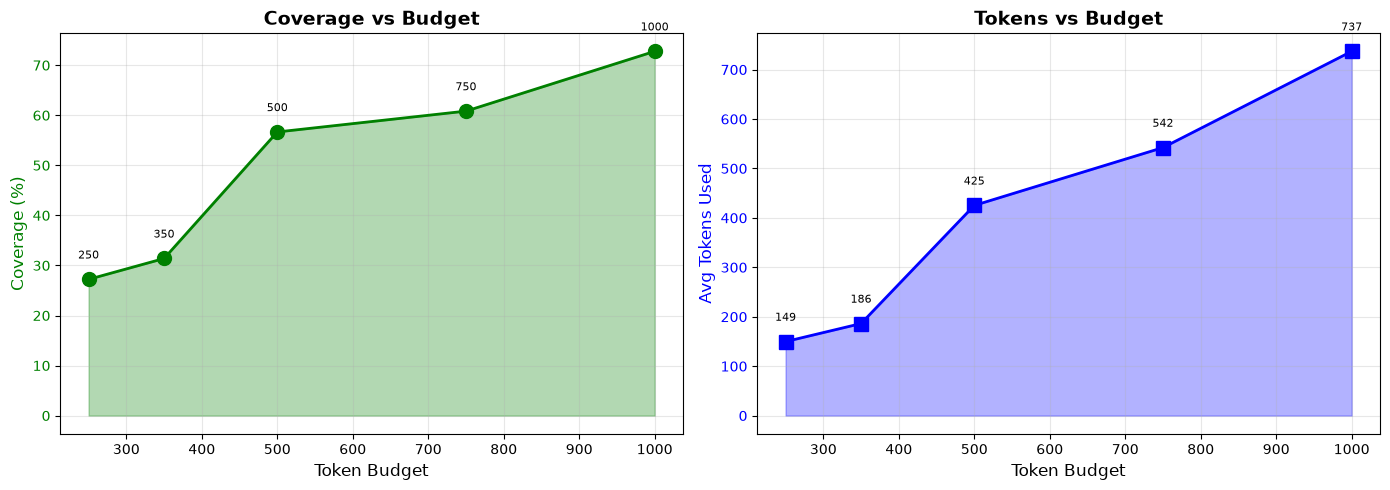

In [175]:
# Plot budget sensitivity
budgets = list(budget_results.keys())
coverage_values = [budget_results[b]["avg_coverage"] * 100 for b in budgets]
tokens_values = [budget_results[b]["avg_tokens"] for b in budgets]
nodes_values = [budget_results[b]["avg_nodes"] for b in budgets]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Coverage vs Budget
ax1.plot(budgets, coverage_values, 'o-', color='green', linewidth=2, markersize=10, label='Coverage')
ax1.fill_between(budgets, coverage_values, alpha=0.3, color='green')
ax1.set_xlabel('Token Budget', fontsize=12)
ax1.set_ylabel('Coverage (%)', fontsize=12, color='green')
ax1.set_title('Coverage vs Budget', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, alpha=0.3)

# Add budget markers
for i, budget in enumerate(budgets):
    ax1.annotate(f'{budget}', (budget, coverage_values[i]), 
                textcoords='offset points', xytext=(0, 15), ha='center', fontsize=8)

# Tokens vs Budget
ax2.plot(budgets, tokens_values, 's-', color='blue', linewidth=2, markersize=10, label='Tokens')
ax2.fill_between(budgets, tokens_values, alpha=0.3, color='blue')
ax2.set_xlabel('Token Budget', fontsize=12)
ax2.set_ylabel('Avg Tokens Used', fontsize=12, color='blue')
ax2.set_title('Tokens vs Budget', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.grid(True, alpha=0.3)

# Add token markers
for i, budget in enumerate(budgets):
    ax2.annotate(f'{int(tokens_values[i])}', (budget, tokens_values[i]), 
                textcoords='offset points', xytext=(0, 15), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'budget_sensitivity.png', dpi=150, bbox_inches='tight')
print("Budget sensitivity plot saved to: budget_sensitivity.png")
